# 📄 CV generator

A self-contained notebook that builds a clean, professional **PDF CV**.

**How to use**
1. Run the cells top to bottom (`Kernel → Restart & Run All`).
2. Edit **`CONFIG`** (your header/contact) and **`SECTIONS`** (the content).
3. Re-run the last cell to rebuild the PDF and preview it inline.

The PDF is written to `research/Bogeng_Song_CV.pdf` next to this notebook.
Fonts use Calibri (headings) + Georgia (body) when available, otherwise the
built-in Helvetica/Times — so it still works on any machine.


In [1]:
# --- One-time setup: install the PDF library if it is missing ---------------
import importlib, subprocess, sys

def _ensure(pkg, mod=None):
    try:
        importlib.import_module(mod or pkg)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

_ensure("reportlab")          # required: builds the PDF
try:
    _ensure("pymupdf", "fitz")  # optional: inline preview of the result
except Exception:
    pass
print("Setup complete.")


Setup complete.


In [2]:
# -*- coding: utf-8 -*-
"""CV rendering engine. You normally do NOT need to edit this cell.
It defines fonts, styles, and the build_cv() function used at the bottom."""
import os, re
from reportlab.lib.pagesizes import LETTER
from reportlab.lib.units import inch
from reportlab.lib import colors
from reportlab.lib.styles import ParagraphStyle
from reportlab.lib.enums import TA_LEFT, TA_RIGHT
from reportlab.platypus import (SimpleDocTemplate, Paragraph, Spacer, Table,
                                TableStyle, HRFlowable, KeepTogether)
from reportlab.pdfbase import pdfmetrics
from reportlab.pdfbase.ttfonts import TTFont

# --------------------------------------------------------------------------
# Fonts: try nice Windows fonts, fall back to the built-in base-14 fonts.
# --------------------------------------------------------------------------
def _register_fonts():
    win = r"C:\Windows\Fonts"
    fams = {}
    def try_family(key, reg, bold, ital, boldital, files):
        try:
            for face, fn in files.items():
                pdfmetrics.registerFont(TTFont(face, os.path.join(win, fn)))
            fams[key] = dict(reg=reg, bold=bold, ital=ital, boldital=boldital)
            return True
        except Exception:
            return False

    body_ok = try_family("body", "CVBody", "CVBody-Bold", "CVBody-Italic", "CVBody-BoldItalic",
        {"CVBody":"georgia.ttf","CVBody-Bold":"georgiab.ttf",
         "CVBody-Italic":"georgiai.ttf","CVBody-BoldItalic":"georgiaz.ttf"})
    head_ok = try_family("head", "CVHead", "CVHead-Bold", "CVHead-Italic", "CVHead-BoldItalic",
        {"CVHead":"calibri.ttf","CVHead-Bold":"calibrib.ttf",
         "CVHead-Italic":"calibrii.ttf","CVHead-BoldItalic":"calibriz.ttf"})

    body = fams.get("body", dict(reg="Times-Roman", bold="Times-Bold",
                                 ital="Times-Italic", boldital="Times-BoldItalic"))
    head = fams.get("head", dict(reg="Helvetica", bold="Helvetica-Bold",
                                 ital="Helvetica-Oblique", boldital="Helvetica-BoldOblique"))

    # Optional CJK font so a Chinese name renders instead of tofu boxes.
    cjk = None
    for fn, idx in [("msyh.ttc", 0), ("msyhbd.ttc", 0), ("simsun.ttc", 0), ("simhei.ttf", None)]:
        try:
            if idx is None:
                pdfmetrics.registerFont(TTFont("CVCJK", os.path.join(win, fn)))
            else:
                pdfmetrics.registerFont(TTFont("CVCJK", os.path.join(win, fn), subfontIndex=idx))
            cjk = "CVCJK"; break
        except Exception:
            continue
    return body, head, cjk

BODY, HEAD, CJK = _register_fonts()

# Palette
ACCENT = colors.HexColor("#2d5a87")
INK    = colors.HexColor("#1b2330")
MUTED  = colors.HexColor("#5b6573")
RULE   = colors.HexColor("#cdd6e0")

def esc(s):
    """Escape stray ampersands but leave intentional entities/tags alone."""
    return re.sub(r"&(?!#?\w+;)", "&amp;", s)

# --------------------------------------------------------------------------
# Paragraph styles
# --------------------------------------------------------------------------
S = {}
S["name"]    = ParagraphStyle("name", fontName=HEAD["bold"], fontSize=22, leading=24, textColor=INK)
S["updated"] = ParagraphStyle("updated", fontName=HEAD["reg"], fontSize=8.5, leading=11,
                              textColor=MUTED, alignment=TA_RIGHT)
S["subtitle"]= ParagraphStyle("subtitle", fontName=BODY["reg"], fontSize=10.5, leading=14, textColor=MUTED)
S["contact"] = ParagraphStyle("contact", fontName=BODY["reg"], fontSize=9.5, leading=13, textColor=INK)
S["section"] = ParagraphStyle("section", fontName=HEAD["bold"], fontSize=12.5, leading=14,
                              textColor=ACCENT, spaceBefore=0, spaceAfter=0)
S["subsec"]  = ParagraphStyle("subsec", fontName=BODY["boldital"], fontSize=10, leading=13,
                              textColor=INK, spaceBefore=2, spaceAfter=2)
S["entry"]   = ParagraphStyle("entry", fontName=BODY["reg"], fontSize=10, leading=13.5, textColor=INK)
S["right"]   = ParagraphStyle("right", fontName=BODY["reg"], fontSize=9.5, leading=13.5,
                              textColor=MUTED, alignment=TA_RIGHT)
S["detail"]  = ParagraphStyle("detail", fontName=BODY["reg"], fontSize=9.5, leading=13,
                              textColor=MUTED, leftIndent=0)
S["links"]   = ParagraphStyle("links", fontName=BODY["reg"], fontSize=9, leading=12, textColor=MUTED)
S["bullet"]  = ParagraphStyle("bullet", fontName=BODY["reg"], fontSize=10, leading=14, textColor=INK,
                              leftIndent=12, firstLineIndent=-12)

DATE_W = 1.25 * inch

def link(label, url):
    # Only hyperlink real URLs; otherwise show plain text (so placeholders don't crash the build).
    if url and re.match(r"^(https?:|mailto:)", url):
        return '<a href="%s" color="#2d5a87"><u>%s</u></a>' % (url, esc(label))
    return esc(label)

def links_line(links):
    valid = [(l, u) for (l, u) in links if u and re.match(r"^(https?:|mailto:)", u)]
    return "  ·  ".join(link(l, u) for (l, u) in valid)

# --------------------------------------------------------------------------
# Flowable builders
# --------------------------------------------------------------------------
def section_header(title):
    out = [Spacer(1, 9),
           Paragraph(esc(title).upper(), S["section"]),
           Spacer(1, 2),
           HRFlowable(width="100%", thickness=1, color=ACCENT, spaceBefore=1, spaceAfter=5)]
    return out

def two_col(left_para, right_text):
    """A title row with a right-aligned date."""
    if right_text:
        t = Table([[left_para, Paragraph(esc(right_text), S["right"])]],
                  colWidths=[None, DATE_W])
    else:
        t = Table([[left_para]], colWidths=[None])
    t.setStyle(TableStyle([
        ("VALIGN", (0,0), (-1,-1), "TOP"),
        ("LEFTPADDING", (0,0), (-1,-1), 0),
        ("RIGHTPADDING", (0,0), (-1,-1), 0),
        ("TOPPADDING", (0,0), (-1,-1), 0),
        ("BOTTOMPADDING", (0,0), (-1,-1), 0),
    ]))
    return t

def render_entry(it):
    """Generic entry: bold title + org, right date, muted detail lines, links."""
    head = "<b>%s</b>" % esc(it["title"])
    if it.get("org"):
        head += "  &mdash; %s" % esc(it["org"])
    flow = [two_col(Paragraph(head, S["entry"]), it.get("right"))]
    for ln in it.get("lines", []):
        flow.append(Paragraph(esc(ln), S["detail"]))
    ll = links_line(it.get("links", []))
    if ll:
        flow.append(Paragraph(ll, S["links"]))
    flow.append(Spacer(1, 6))
    return KeepTogether(flow)

def render_pub(it, num=None):
    prefix = ("%s. " % num) if num else ""
    parts = []
    if it.get("authors"):
        parts.append(esc(it["authors"]))
    if it.get("title"):
        parts.append("<b>%s</b>" % esc(it["title"]))
    if it.get("venue"):
        parts.append("<i>%s</i>" % esc(it["venue"]))
    body = prefix + " ".join(parts)
    ll = links_line(it.get("links", []))
    if ll:
        body += "  " + ll
    flow = [two_col(Paragraph(body, S["entry"]), it.get("year"))]
    flow.append(Spacer(1, 6))
    return KeepTogether(flow)

def render_pubs(sec):
    flow = list(section_header(sec["title"]))
    if sec.get("note"):
        flow.append(Paragraph("<i>%s</i>" % esc(sec["note"]), S["detail"]))
        flow.append(Spacer(1, 4))
    for grp in sec["groups"]:
        flow.append(Paragraph(esc(grp["subtitle"]), S["subsec"]))
        flow.append(Spacer(1, 3))
        items = grp["items"]
        prefix = grp.get("prefix")
        n = len(items)
        for i, it in enumerate(items):
            num = ("%s%d" % (prefix, n - i)) if prefix else None
            flow.append(render_pub(it, num))
    return flow

def render_entries(sec):
    flow = list(section_header(sec["title"]))
    for it in sec["items"]:
        flow.append(render_entry(it))
    return flow

def render_list(sec):
    flow = list(section_header(sec["title"]))
    for it in sec["items"]:
        if isinstance(it, dict):
            txt = "<b>%s:</b> %s" % (esc(it["label"]), esc(it["text"]))
        else:
            txt = esc(it)
        flow.append(Paragraph("&bull;&nbsp;&nbsp;" + txt, S["bullet"]))
    return flow

RENDERERS = {"entries": render_entries, "pubs": render_pubs, "list": render_list}

def header_flow(cfg):
    name_html = esc(cfg["name"])
    if cfg.get("name_cjk") and CJK:
        name_html += ' <font name="%s">%s</font>' % (CJK, esc(cfg["name_cjk"]))
    name_tbl = Table([[Paragraph(name_html, S["name"]),
                       Paragraph("Updated: %s" % esc(cfg["updated"]), S["updated"])]],
                     colWidths=[None, 1.6*inch])
    name_tbl.setStyle(TableStyle([
        ("VALIGN", (0,0), (-1,-1), "BOTTOM"),
        ("LEFTPADDING", (0,0), (-1,-1), 0), ("RIGHTPADDING", (0,0), (-1,-1), 0),
        ("TOPPADDING", (0,0), (-1,-1), 0), ("BOTTOMPADDING", (0,0), (-1,-1), 0),
    ]))
    flow = [name_tbl, Spacer(1, 3),
            Paragraph(esc(cfg["subtitle"]), S["subtitle"]),
            Spacer(1, 3),
            Paragraph(links_line(cfg["contact"]), S["contact"]),
            Spacer(1, 5),
            HRFlowable(width="100%", thickness=1.4, color=ACCENT)]
    return flow

def build_cv(cfg, sections, outpath):
    doc = SimpleDocTemplate(outpath, pagesize=LETTER,
                            leftMargin=0.85*inch, rightMargin=0.85*inch,
                            topMargin=0.7*inch, bottomMargin=0.7*inch,
                            title="%s — CV" % cfg["name"], author=cfg["name"])
    story = header_flow(cfg)
    for sec in sections:
        story += RENDERERS[sec["kind"]](sec)
    doc.build(story)
    return outpath

## ✏️ Your details — edit the next two cells

In [5]:
import datetime

# ====== YOUR HEADER / CONTACT INFO — edit freely ======
CONFIG = {
    "name": "Bogeng Song",
    "name_cjk": "宋伯耕",
    "updated": datetime.date.today().strftime("%B %Y"),  # auto-updates to today
    "subtitle": "PhD Student, Psychology · Georgia Institute of Technology  ·  Advisor: Dobromir Rahnev",
    "contact": [
        ("bsong91@gatech.edu", "mailto:bsong91@gatech.edu"),
        ("bogeng-song.github.io", "https://bogeng-song.github.io"),
        ("Google Scholar", "https://scholar.google.com/citations?user=7Sex-LYAAAAJ&hl=en"),
        ("GitHub", "https://github.com/bogeng-song"),
    ],
}

In [11]:
SECTIONS = [
    {"kind": "entries", "title": "Education", "items": [
        {"title": "PhD in Psychology", "org": "Georgia Institute of Technology",
         "right": "Present",
         "lines": ["Advisor: Dobromir (Doby) Rahnev",
                   "Computational cognitive science & metacognition"]},
        {"title": "MA in Psychology", "org": "New York University",
         "right": "",
         "lines": ["Worked with Grace Lindsay, Marisa Carrasco"]},
    ]},

    {"kind": "entries", "title": "Training & Summer Schools", "items": [
        {"title": "NeuroAI", "org": "Neuromatch Academy", "right": "Summer 2025",
         "lines": ["Deep learning as a framework for understanding brains and behavior"]},
        {"title": "Computational Neuroscience", "org": "Neuromatch Academy", "right": "Summer 2022",
         "lines": ["Models of neural dynamics, decision-making, and learning"]},
    ]},

    {"kind": "pubs", "title": "Publications & Presentations",
     "note": "† indicates equal contribution; underlined links are clickable.",
     "groups": [
        {"subtitle": "Journal Articles", "prefix": "J", "items": [
            {"authors": "R. Ezzo, <b>B. Song</b>, B. Rokers, &amp; M. Carrasco.",
             "year": "2025",
             "title": "Eyes on hold: motion task difficulty jointly delays microsaccade and pupil responses.",
             "venue": "Scientific Reports.",
             "links": [("Article", "https://www.nature.com/articles/s41598-025-04748-0"),
                       ("DOI", "https://doi.org/10.1038/s41598-025-04748-0")]},
            {"authors": "X. Lu&#8224;, <b>B. Song&#8224;</b>, S. Zhang, S. Zhang, M. Huang, Y. Wang, &amp; Y. Jiang.",
             "year": "2025",
             "title": "Implied gravity promotes coherent motion perception.",
             "venue": "npj Microgravity.",
             "links": [("Article", "https://www.nature.com/articles/s41526-025-00498-5"),
                       ("DOI", "https://doi.org/10.1038/s41526-025-00498-5")]},
        ]},
        {"subtitle": "Preprints", "prefix": "P", "items": [
            {"authors": "N. C. Benson, <b>B. Song</b>, S. Chen, T. Miyata, H. Takemura, &amp; J. Winawer.",
             "year": "2025",
             "title": "Machine learning matches human performance at segmenting the human visual cortex.",
             "venue": "bioRxiv.",
             "links": [("Preprint", "https://www.biorxiv.org/content/10.1101/2025.05.16.654503v1.full"),
                       ("DOI", "https://doi.org/10.1101/2025.05.16.654503")]},
        ]},
        {"subtitle": "Conference Presentations", "prefix": "C", "items": [
            {"authors": "<b>B. Song</b>, &amp; D. Rahnev",
             "year": "2026",
             "title": "A Computational Signature of Self-Monitoring in Perceptual Confidence",
             "venue": "Cognitive Computational Neuroscience (CCN, 2026)."},
            {"authors": "Q. Yang, H. W. Han, <b>B. Song</b>, J. Golomb, D. Rahnev, Y. Mohsenzadeh, &amp; H.-H. Li.",
             "year": "2026",
             "title": "Hierarchical representational transformations of working memory in brains and machines.",
             "venue": "Cognitive Computational Neuroscience (CCN, 2026)."},
            {"authors": "<b>B. Song</b>, &amp; D. Rahnev.", "year": "2025",
             "title": "The influence of response bias on confidence and accuracy in multi-alternative tasks for humans and artificial neural networks.",
             "venue": "Vision Sciences Society (VSS,2025); Journal of Vision."},
            {"authors": "N. C. Benson, <b>B. Song</b>, T. Miyata, H. Takemura, &amp; J. Winawer.",
             "year": "2023",
             "title": "Automated delineation of visual area boundaries and eccentricities by a CNN using functional, anatomical, and diffusion-weighted MRI data.",
             "venue": "MODVIS (VSS satellite workshop)."},
            {"authors": "R. Ezzo, <b>B. Song</b>, B. Rokers, &amp; M. Carrasco.", "year": "2023",
             "title": "Microsaccade rates reflect trial difficulty for perifoveal motion discrimination.",
             "venue": "Vision Sciences Society (VSS); Journal of Vision.",
             "links": [("Abstract", "https://www.visionsciences.org/presentation/?id=5177")]},
        ]},
     ]},


    {"kind": "entries", "title": "Coursework & Course Projects", "items": [
        {"title": "Differential contributions of episodic and semantic memory to story-telling",
         "org": "Computational Cognitive Modeling , NYU", "right": "",
         "lines": ["ML classification of recalled / imagined / retold stories; "
                   "feature importance linked to episodic vs. semantic memory theory."]},
        {"title": "Bayesian semi-supervised learning with function-space variational inference",
         "org": "Bayesian Machine Learning, NYU", "right": "",
         "lines": ["Combined function-space variational inference with maximum-uncertainty "
                   "regularization; evaluated on SVHN and CIFAR-10."]},
        {"title": "Other relevant coursework", "org": "", "right": "",
         "lines": ["Machine Learning (NYU, Center for Data Science) · "
                   "Artificial Intelligence (Georgia Tech, School of Computer Science)"]},
    ]},

    {
  "kind": "list",
  "title": "Skills",
  "items": [
    {
      "label": "Programming & web",
      "text": "Python, MATLAB, R, JavaScript, HTML, CSS"
    },
    {
      "label": "Scientific computing & data analysis",
      "text": "NumPy, SciPy, Pandas, Matplotlib, statistical analysis, data visualization"
    },
    {
      "label": "Machine learning & computational modeling",
      "text": "PyTorch, scikit-learn, deep neural network modeling, Bayesian methods, cognitive modeling, model fitting and simulation"
    },
    {
      "label": "Behavioral and experimental methods",
      "text": "Psychophysics, eye-tracking, experimental design, behavioral data analysis, perceptual decision-making tasks"
    },
    {
      "label": "Neuroimaging & NeuroAI",
      "text": "fMRI analysis, neural data analysis, visual-system modeling, representational analysis, deep networks as models of brain and behavior"
    },
    {
      "label": "Tools & workflow",
      "text": "PsychoPy, Git/GitHub, LaTeX, Jupyter, reproducible research workflows"
    },
    {
      "label": "Emerging AI interests",
      "text": "Large language models, vision-language models, reinforcement learning, human-AI comparison, learning and generalization"
    }
  ]
}
]


## ➕ Adding your own sections later

`SECTIONS` is just a list of dictionaries, rendered top to bottom. Three kinds:

- **`"entries"`** — a list of items, each `{"title", "org", "right", "lines", "links"}`.
  Use this for Education, Training, Teaching, Awards, Service, etc.
- **`"pubs"`** — grouped, auto-numbered publications (Journal `J`, Preprint `P`, Conference `C`).
- **`"list"`** — simple bullets (plain strings, or `{"label", "text"}`), used for Skills.

Every field is optional except `title`. `links` is a list of `(label, url)` pairs;
a link with an empty/placeholder URL is automatically left out of the PDF.

**Example — add a Teaching section.** Paste a block like this into `SECTIONS`
(wherever you want it to appear), then re-run the build cell:

```python
{"kind": "entries", "title": "Teaching", "items": [
    {"title": "Teaching Assistant — PSYC XXXX: Course Name",
     "org": "Georgia Institute of Technology", "right": "Fall 2026",
     "lines": ["Led recitations, graded assignments, held office hours."]},
]},
```

Or append it programmatically in a new cell:

```python
SECTIONS.append({"kind": "list", "title": "Awards & Scholarships",
                 "items": ["Some Award (2026)", "Another Fellowship (2025)"]})
```


PDF written to: d:\Github\bogeng-song.github.io\research\Bogeng_Song_CV.pdf


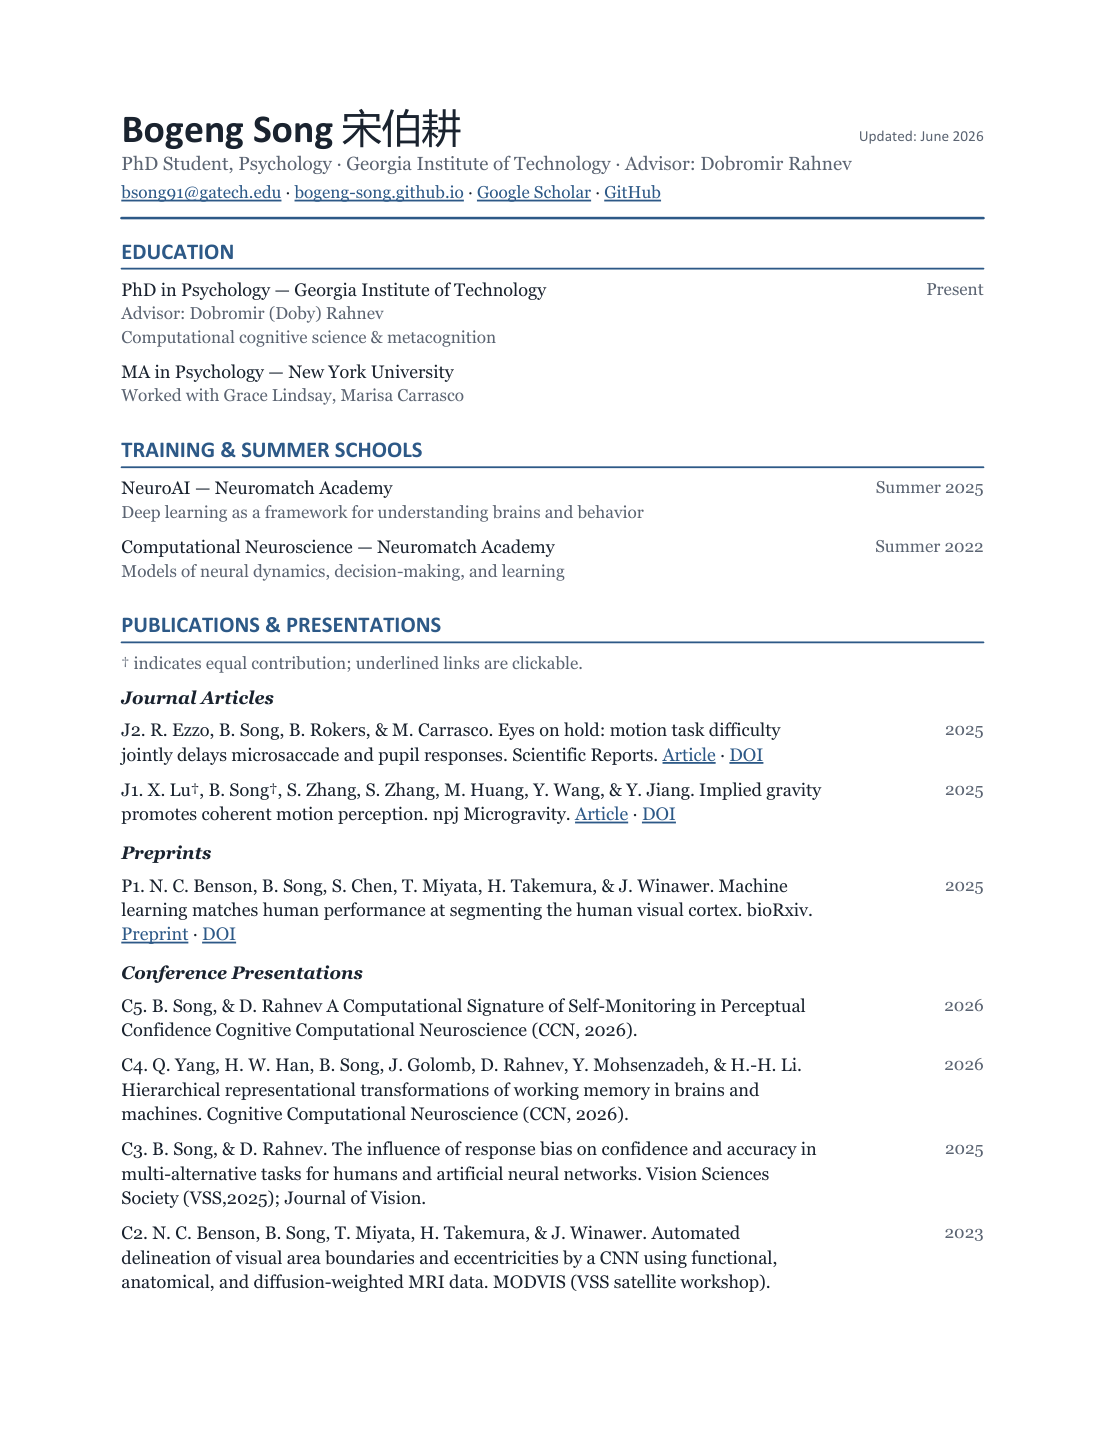

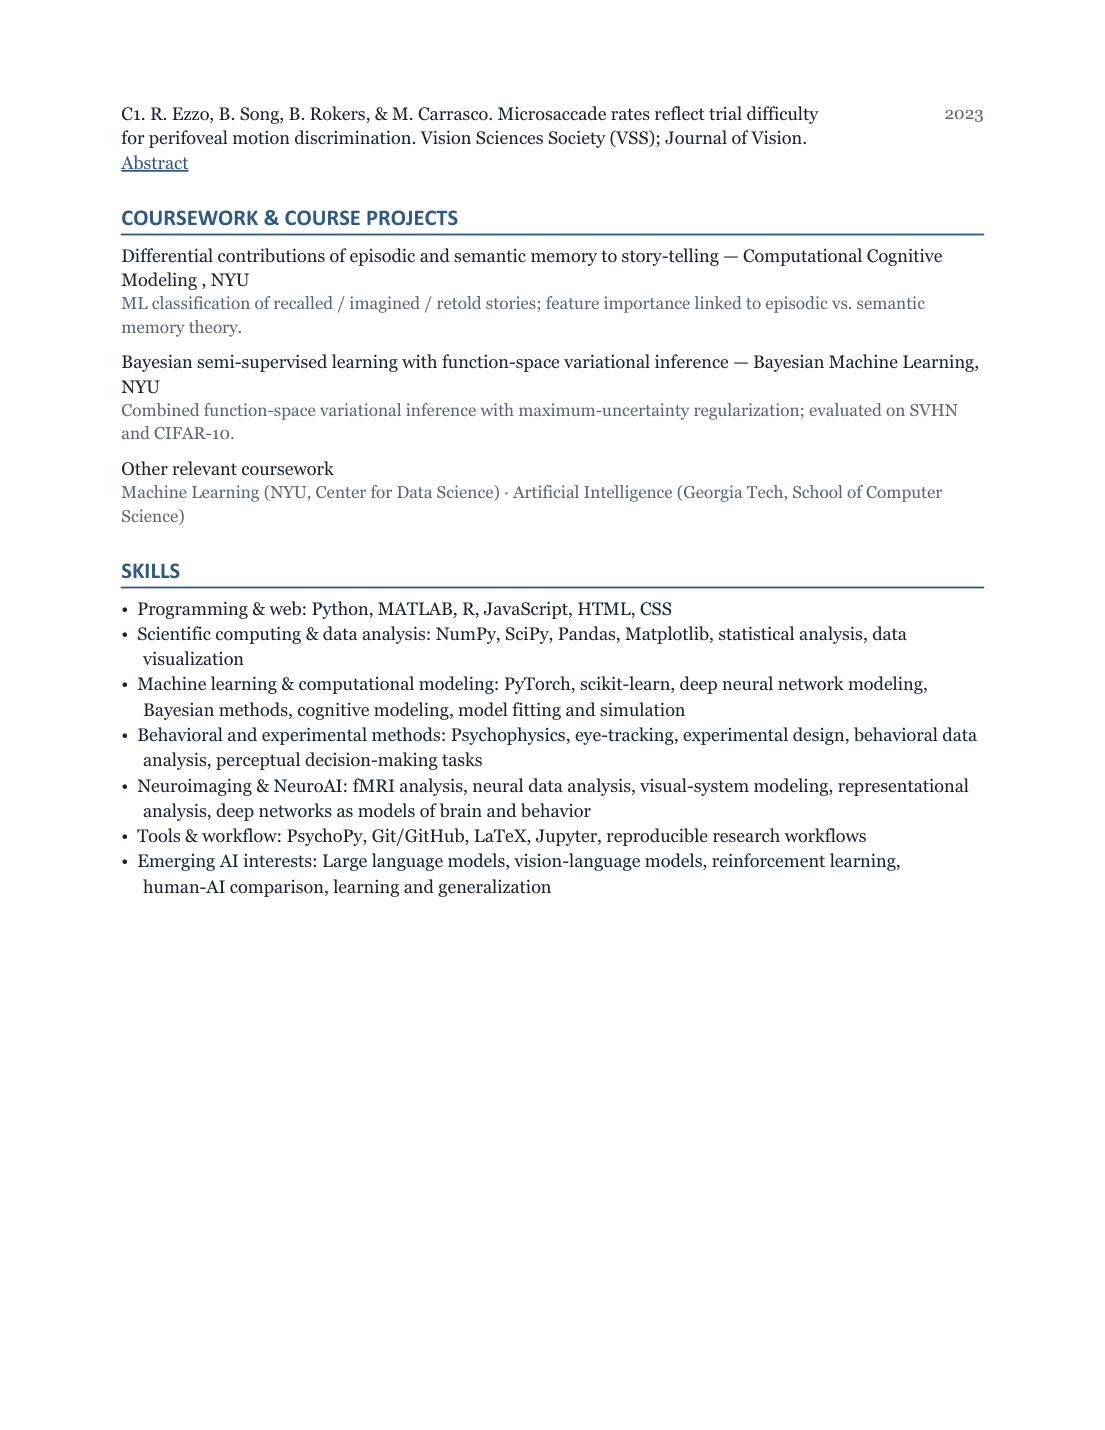

In [12]:
# --- Build the PDF, then show an inline preview -----------------------------
import os

OUT = "research/Bogeng_Song_CV.pdf"   # output path, relative to this notebook
# Tip: to replace the CV linked on your website, set OUT = "research/Bogeng_CV.pdf"

os.makedirs(os.path.dirname(OUT), exist_ok=True)
build_cv(CONFIG, SECTIONS, OUT)
print("PDF written to:", os.path.abspath(OUT))

# Inline preview (skipped silently if pymupdf is not installed)
try:
    import fitz
    from IPython.display import Image, display
    doc = fitz.open(OUT)
    for i, pg in enumerate(doc):
        png = f"_cv_preview_p{i+1}.png"
        pg.get_pixmap(dpi=130).save(png)
        display(Image(filename=png))
    doc.close()
except Exception as e:
    print("(Inline preview skipped:", e, ")")
